# Sudoku board threshold experiment

Ten notebook zaczyna eksperyment od zera i prowadzi teraz pipeline do etapu:
- wczytanie obrazu,
- grayscale,
- odszumianie,
- `adaptive threshold`,
- lekkie czyszczenie binarki po thresholdzie,
- naprawa linii i budowa logicznych rodzin,
- znalezienie ramek planszy,
- porównanie dwóch wariantów warp na podstawie wykrytej ramki.

Wciąż nie ma tutaj jeszcze:
- korekcji EXIF,
- cięcia na siatkę 9x9,
- modelowania nieliniowego zagięcia kartki.

To ma być mały, szybki poligon do porównywania wariantów preprocessingu, linii, ramek i warpu na obrazkach z datasetu. Kolejne bloki będziemy dokładać dopiero wtedy, gdy ten etap będzie stabilny.

In [933]:
import importlib

from sudoku_board_threshold_notebook_bootstrap import load_threshold_notebook_api
import sudoku_board_threshold_notebook_pipeline as threshold_pipeline
import sudoku_board_threshold_notebook_report as threshold_report

threshold_pipeline = importlib.reload(threshold_pipeline)
threshold_report = importlib.reload(threshold_report)

from sudoku_board_threshold_notebook_pipeline import (
    configure_manual_image_path,
    describe_cleanup_stage,
    describe_denoise_stage,
    describe_loaded_image,
    describe_threshold_stage,
    resolve_active_image_selection,
    run_threshold_preprocess_pipeline,
)
from sudoku_board_threshold_notebook_report import (
    build_frame_debug_plot_items,
    build_line_debug_plot_items,
    build_warp_debug_plot_items,
    describe_frame_debug_artifacts,
    describe_line_debug_artifacts,
    describe_warp_debug_artifacts,
    run_frame_debug_analysis,
    run_line_debug_analysis,
    run_warp_debug_analysis,
)

API = load_threshold_notebook_api()
ExperimentConfig = API.ExperimentConfig
REPO_ROOT = API.REPO_ROOT
DRAFT_DIR = API.DRAFT_DIR

In [934]:
API = load_threshold_notebook_api()
ExperimentConfig = API.ExperimentConfig
REPO_ROOT = API.REPO_ROOT
DRAFT_DIR = API.DRAFT_DIR

print("Reloaded threshold notebook API and dependent modules.")

Reloaded threshold notebook API and dependent modules.


In [935]:
CONFIG = ExperimentConfig(
    # Delikatna kalibracja HoughLinesP: trochę łatwiej łapiemy krótsze segmenty
    # i pozwalamy na minimalnie większą lukę między ich częściami.
    raw_hough_threshold=32,
    raw_min_line_length_ratio=0.07,
    raw_max_line_gap_ratio=0.014,
)

print(f"Repo root: {REPO_ROOT}")
print(f"Draft dir:  {DRAFT_DIR}")
print(f"Dataset root (current): {CONFIG.dataset_root}")
print(f"Hough threshold: {CONFIG.raw_hough_threshold}")
print(f"Hough min line length ratio: {CONFIG.raw_min_line_length_ratio}")
print(f"Hough max line gap ratio: {CONFIG.raw_max_line_gap_ratio}")


Repo root: /home/wojtek/projects/sudoku
Draft dir:  /home/wojtek/projects/sudoku/src/MachineLearning/draft
Dataset root (current): /home/wojtek/projects/sudoku/data/raw/boards
Hough threshold: 32
Hough min line length ratio: 0.07
Hough max line gap ratio: 0.014


## 1. Wybór obrazka

Są dwa tryby pracy:
1. ręczne wpisanie ścieżki do konkretnego obrazka,
2. automatyczny wybór pliku z `CONFIG.dataset_root` po indeksie.

Najprostszy workflow:
1. wpisz ścieżkę w komórce poniżej, jeśli chcesz pracować na jednym konkretnym obrazie,
2. jeśli pole zostanie puste, notebook użyje `CONFIG.dataset_root` i `CONFIG.selected_dataset_index`,
3. uruchom dalsze komórki.

Domyślnie **nie** stosujemy żadnej automatycznej korekcji orientacji. Chcemy zobaczyć obraz dokładnie takim, jaki trafia do pipeline'u.

In [ ]:
IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/examples/uploads/image175.jpg"
# Przykład:
# IMAGE_PATH_INPUT = "/home/wojtek/projects/sudoku/data/raw/boards/przyklad/board_01.jpg"
# IMAGE_PATH_INPUT = "data/raw/boards/przyklad/board_01.jpg"

print(configure_manual_image_path(CONFIG, IMAGE_PATH_INPUT, REPO_ROOT))

Manual image path enabled: /home/wojtek/projects/sudoku/examples/uploads/image1087.jpg


In [937]:
IMAGE_SELECTION = resolve_active_image_selection(CONFIG, API)
ACTIVE_IMAGE_PATH = IMAGE_SELECTION.active_image_path
DATASET_IMAGES = IMAGE_SELECTION.dataset_images

for line in IMAGE_SELECTION.preview_lines:
    print(line)

Found 559 image(s) under dataset root.
[00] mixed/image1005.jpg
[01] mixed/image1009.jpg
[02] mixed/image1019.jpg
[03] mixed/image1024.jpg
[04] mixed/image1041.jpg
[05] mixed/image1072.jpg
[06] mixed/image1073.jpg
[07] mixed/image1080.jpg
[08] mixed/image1088.jpg
[09] mixed/image114.jpg
[10] mixed/image117.jpg
[11] mixed/image120.jpg
[12] mixed/image126.jpg
[13] mixed/image140.jpg
[14] mixed/image148.jpg
[15] mixed/image153.jpg
[16] mixed/image166.jpg
[17] mixed/image175.jpg
[18] mixed/image176.jpg
[19] mixed/image179.jpg
... and 539 more

Active image: /home/wojtek/projects/sudoku/examples/uploads/image1087.jpg


In [938]:
PREPROCESS_RESULT = run_threshold_preprocess_pipeline(
    ACTIVE_IMAGE_PATH,
    CONFIG,
    API,
)
source_bgr = PREPROCESS_RESULT.source_bgr
display_bgr = PREPROCESS_RESULT.display_bgr
gray_image = PREPROCESS_RESULT.gray_image

for line in describe_loaded_image(PREPROCESS_RESULT):
    print(line)

Original shape: (1280, 960, 3)
Display shape:  (1280, 960, 3)


## 2. Odszumianie

Najpierw porównujemy kilka prostych wariantów odszumiania. Na tym etapie chodzi tylko o szybkie sprawdzenie, który wariant najlepiej zachowuje linie siatki i nie rozmywa ich zbyt agresywnie.

In [939]:
for line in describe_denoise_stage(PREPROCESS_RESULT):
    print(line)

Available denoise variants:
- raw_gray
- gaussian_5
- median_5 <-- selected
- bilateral
- nl_means


## 3. Adaptive threshold

Dalej porównujemy kilka kombinacji `blockSize` i `C` na jednym, wybranym wariancie odszumiania.

Po wybraniu najlepszego progu robimy jeszcze lekki `binary cleanup`, bo właśnie ten etap dawał lepszy efekt w `sudoku_board_frame_debug_split.ipynb` niż sama zmiana filtra odszumiającego na grayscale.

In [940]:
for line in describe_threshold_stage(PREPROCESS_RESULT, CONFIG):
    print(line)

Adaptive method: gaussian
Selected denoise variant: median_5

Available threshold variants:
- gaussian_block11_c2 <-- selected
- gaussian_block11_c4
- gaussian_block11_c6
- gaussian_block15_c2
- gaussian_block15_c4
- gaussian_block15_c6
- gaussian_block21_c2
- gaussian_block21_c4
- gaussian_block21_c6
- gaussian_block31_c2
- gaussian_block31_c4
- gaussian_block31_c6


In [941]:
selected_denoise_image = PREPROCESS_RESULT.selected_denoise_image
SELECTED_THRESHOLD_NAME = PREPROCESS_RESULT.selected_threshold_name
selected_binary = PREPROCESS_RESULT.selected_binary
min_component_area_px = PREPROCESS_RESULT.min_component_area_px
cleanup_variants = PREPROCESS_RESULT.cleanup_variants
SELECTED_CLEANUP_NAME = PREPROCESS_RESULT.selected_cleanup_name
selected_clean_binary = PREPROCESS_RESULT.selected_clean_binary
repair_variants = PREPROCESS_RESULT.repair_variants
SELECTED_REPAIR_NAME = PREPROCESS_RESULT.selected_repair_name
selected_repaired_binary = PREPROCESS_RESULT.selected_repaired_binary

for line in describe_cleanup_stage(PREPROCESS_RESULT):
    print(line)


Selected cleanup variant: adaptive_plus_components_soft
Selected repair variant: directional_close
Connected components min area px: 74
Available cleanup variants: adaptive_only, adaptive_plus_components_soft, adaptive_plus_components
Available repair variants: cleanup_only, close_square_3, close_square_5, directional_close

Notebook continues with line-family visualization below.
Next blocks should start from `selected_repaired_binary` and its detected line families.


## 4. Naprawa linii, rodziny i scalanie

Ta sekcja nie pokazuje już wszystkich wariantów po kolei. Skupiamy się tylko na aktualnie wybranej ścieżce:
- `selected_binary`,
- `selected_cleanup`,
- `selected_repair`,
- końcowe rodziny `horizontal` i `vertical`,
- logiczne grupy segmentów w każdej rodzinie.

Segmenty łączą się tylko w obrębie tej samej rodziny. Jeśli A łączy się z B, a B z C, to na końcu traktujemy je jako jedną logiczną grupę wielu małych segmentów. Nie rysujemy sztucznej prostej między skrajnymi końcami. Zapisujemy za to:
- obwiednię grupy (`span`),
- realne pokrycie przez segmenty (`covered`),
- sumę długości surowych segmentów (`raw_len`),
- liczbę przeciętych linii z drugiej rodziny,
- liczbę punktów styczności.

Końcową selekcję robimy teraz iteracyjnie. Startujemy od pełnego zbioru logicznych linii po scalaniu i bridge repair, zostawiamy tylko te, które mają co najmniej `CONFIG.min_cross_family_touches_to_keep` punktów styczności, potem liczymy przecięcia jeszcze raz już na przefiltrowanym zbiorze i powtarzamy ten krok tak długo, aż nic więcej nie odpadnie. Dopiero taki stabilny zbiór pokazujemy jako finalną wersję. Na overlayach każda zachowana grupa ma własny kolor, żeby było od razu widać, czy segmenty zostały zgrupowane sensownie.


Line families from selected repair:
Raw Hough segments: 845
Raw min line length px: 67
Raw max line gap px: 13
Merge projection distance px: 11.5
Merge endpoint gap px: 24.0
Bridge projection tolerance px: 26.9
Bridge max gap px: 62.4
Bridge endpoint tolerance px: 26.9
Cross-family touch tolerance px: 19.2
Horizontal repaired bridges: 9
Vertical repaired bridges: 55
Min cross-family touch points to keep per iteration: 2
Expected kept lines: H=10, V=10
Horizontal family angle: 0.0 deg
Vertical family angle: 90.0 deg
Horizontal raw segments: 559
Vertical raw segments: 279
Horizontal logical groups before touch filter: 24
Vertical logical groups before touch filter: 19
Horizontal kept logical groups (after refresh): 12
Vertical kept logical groups (after refresh): 17

NOT YET: expected exactly 10 horizontal and 10 vertical logical lines.

Horizontal kept logical groups:
  H0: span=731.0px, covered=731.0px, segments=7, raw_len=2956.0px, touch_lines=10, touch_points=10, vertical_ids=[1, 3,

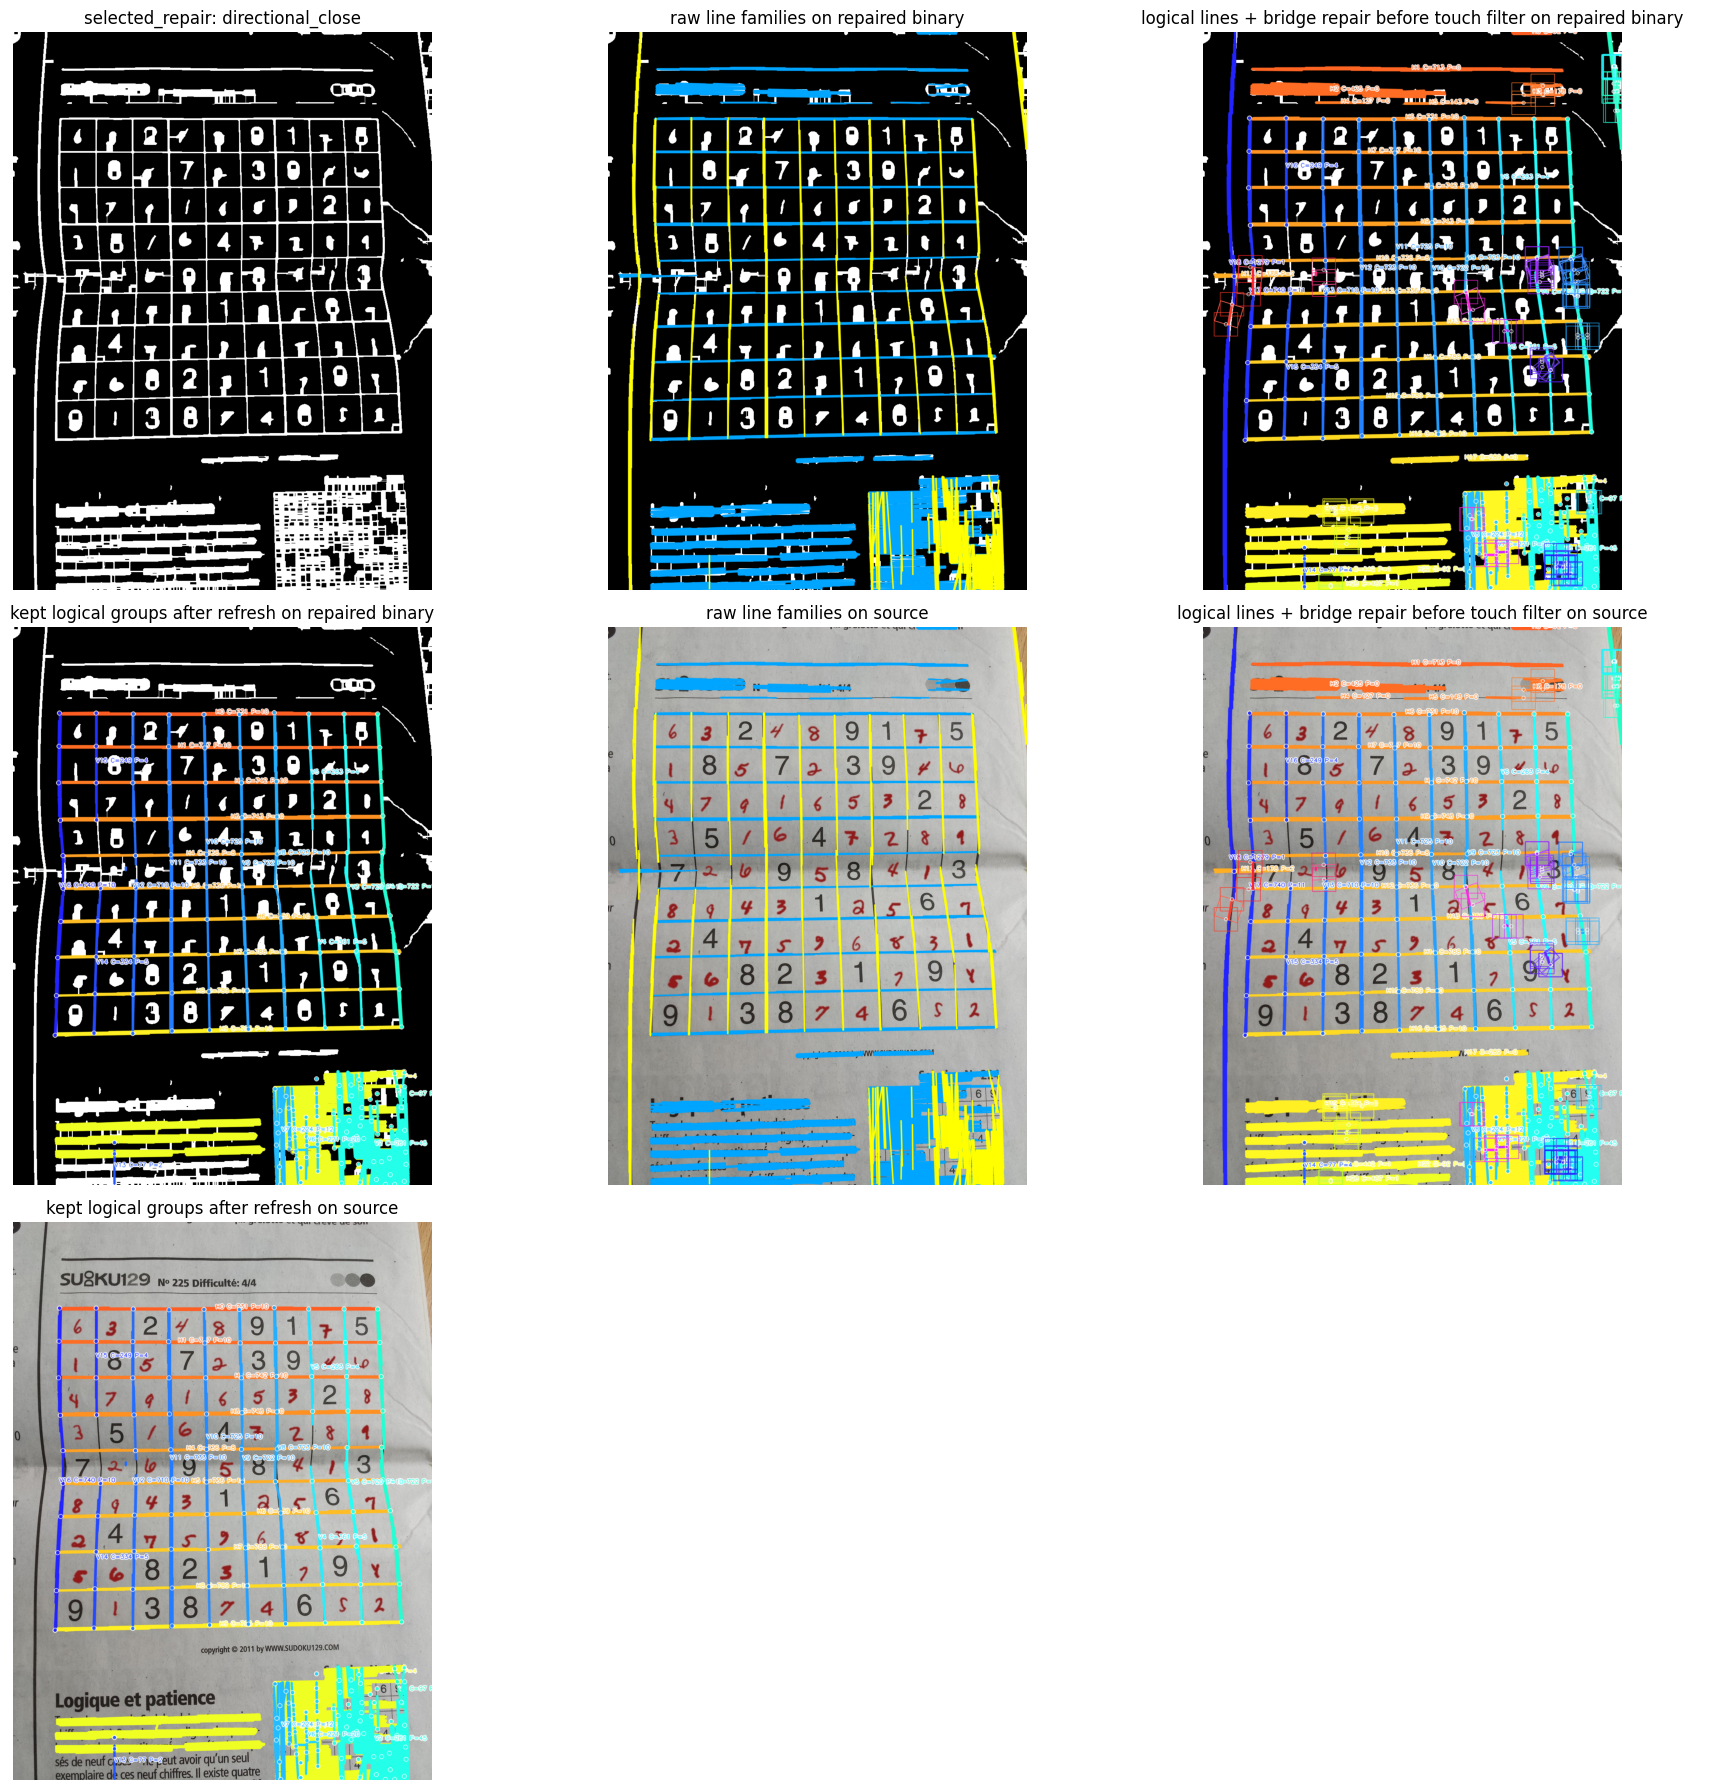

In [942]:
LINE_DEBUG = run_line_debug_analysis(
    PREPROCESS_RESULT.display_bgr,
    PREPROCESS_RESULT.selected_repaired_binary,
    CONFIG,
    API,
)
line_family_result = LINE_DEBUG.line_family_result
binary_merged_overlay = LINE_DEBUG.binary_merged_overlay
source_merged_overlay = LINE_DEBUG.source_merged_overlay

for line in describe_line_debug_artifacts(
    LINE_DEBUG,
    CONFIG,
    API,
    include_vertices=False,
):
    print(line)

API.plot_named_images(
    build_line_debug_plot_items(
        LINE_DEBUG,
        PREPROCESS_RESULT.selected_repair_name,
        include_vertices=False,
    ),
    columns=3,
    figure_scale=6,
)


Line families from selected repair:
Raw Hough segments: 845
Raw min line length px: 67
Raw max line gap px: 13
Merge projection distance px: 11.5
Merge endpoint gap px: 24.0
Bridge projection tolerance px: 26.9
Bridge max gap px: 62.4
Bridge endpoint tolerance px: 26.9
Cross-family touch tolerance px: 19.2
Horizontal repaired bridges: 9
Vertical repaired bridges: 55
Mutual last-touch endpoint pairs: 6
Min cross-family touch points to keep per iteration: 2
Expected kept lines: H=10, V=10
Horizontal family angle: 0.0 deg
Vertical family angle: 90.0 deg
Horizontal raw segments: 559
Vertical raw segments: 279
Horizontal logical groups before touch filter: 24
Vertical logical groups before touch filter: 19
Horizontal kept logical groups (after refresh): 12
Vertical kept logical groups (after refresh): 17

NOT YET: expected exactly 10 horizontal and 10 vertical logical lines.

Horizontal kept logical groups with vertices:
  H0: span=731.0px, covered=731.0px, segments=7, raw_len=2956.0px, to

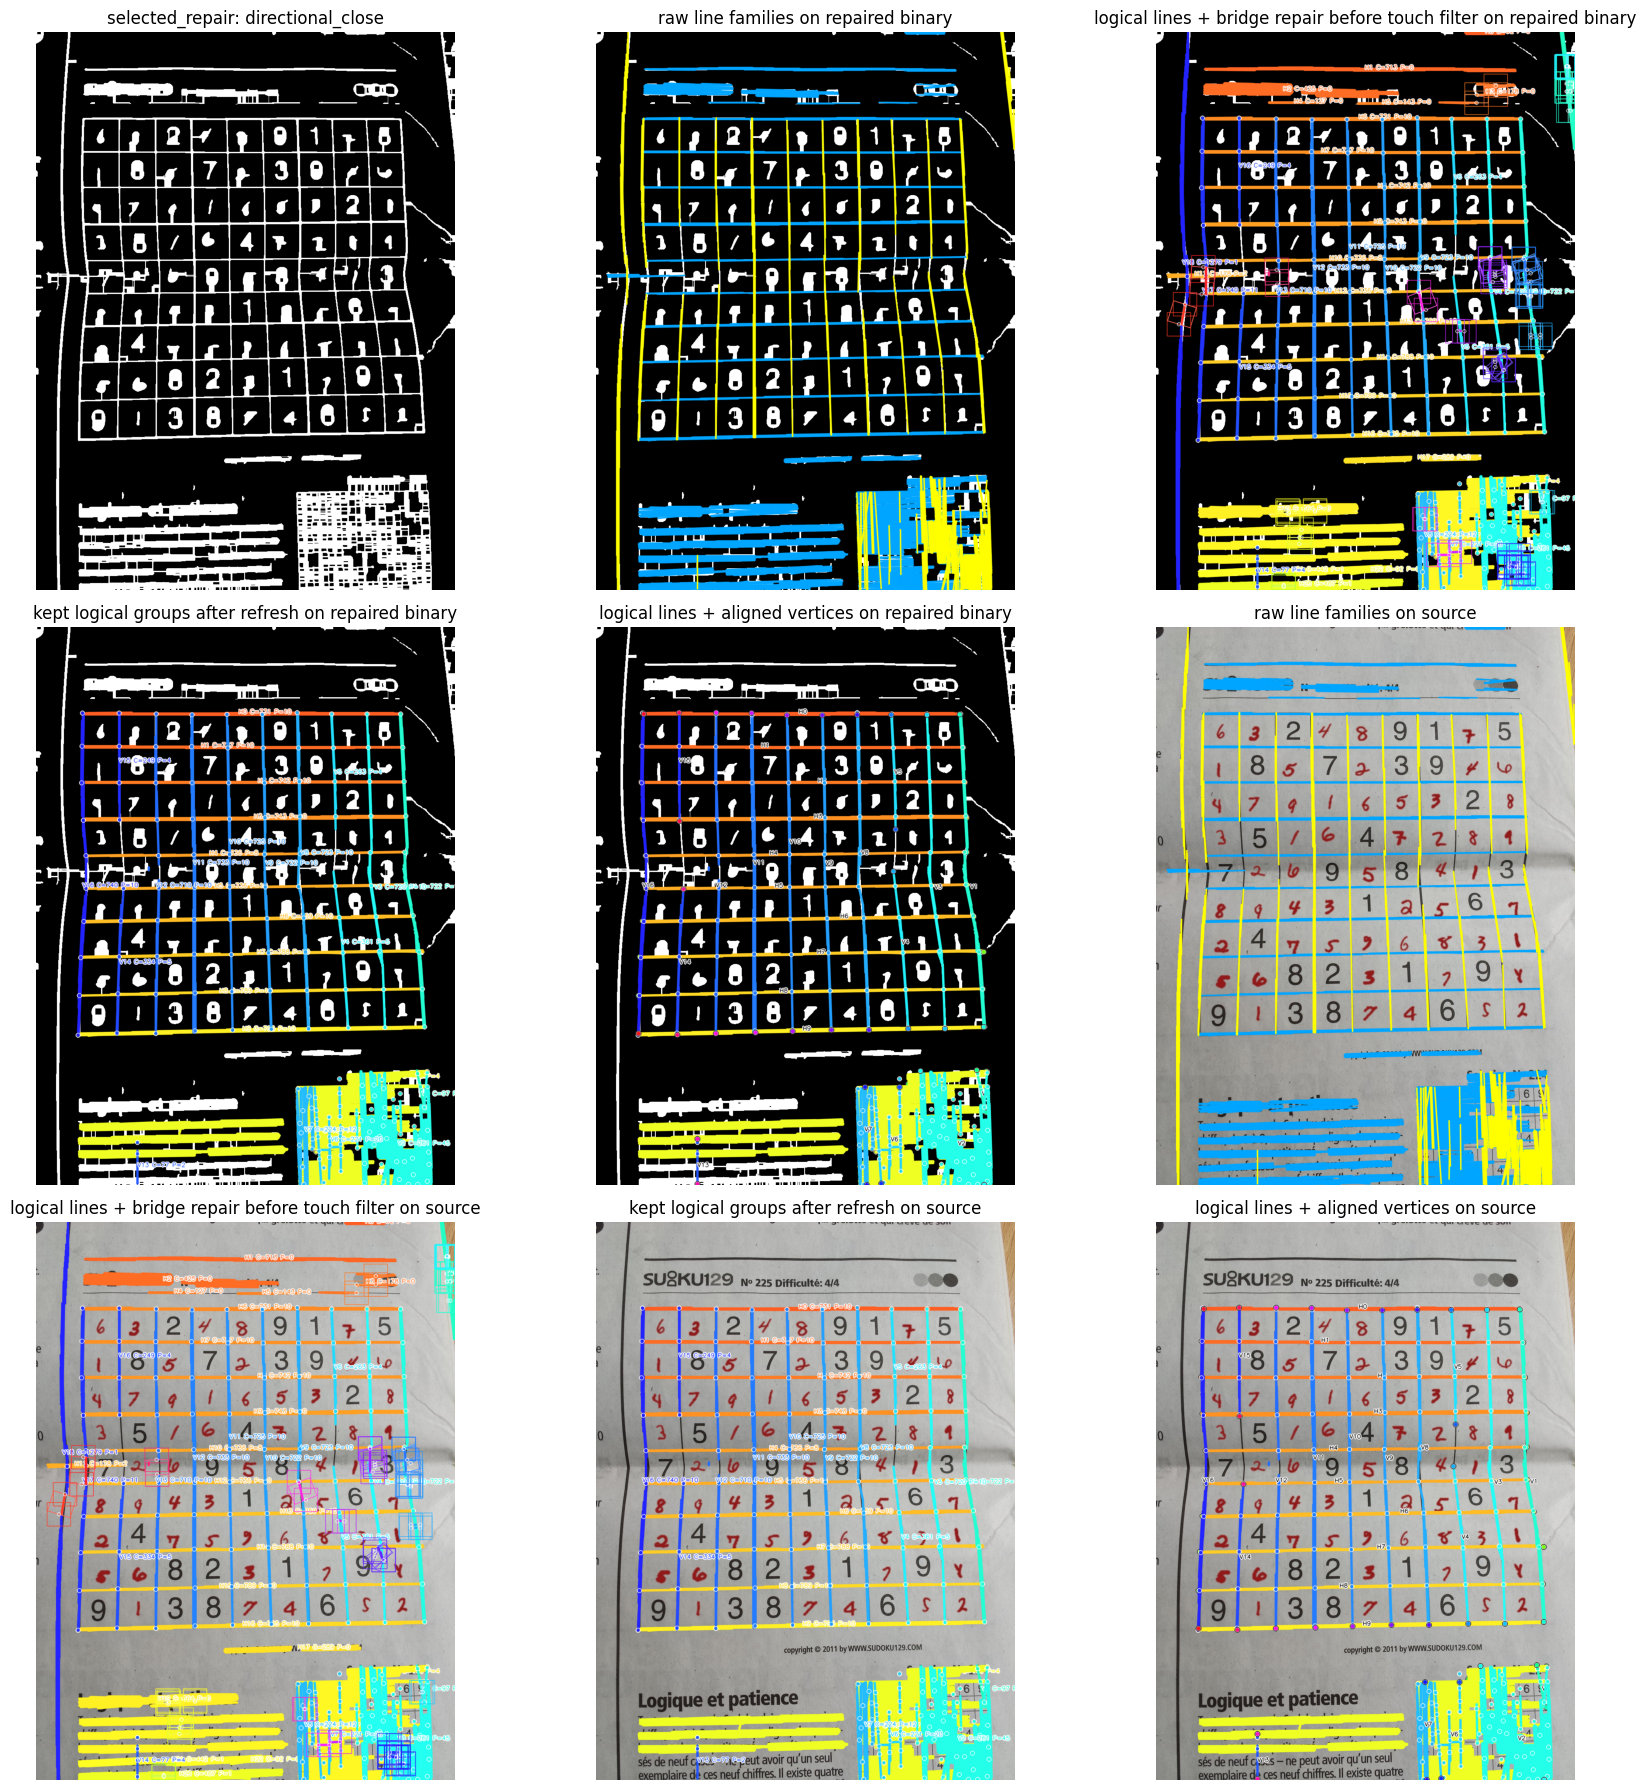

In [943]:
LINE_DEBUG = run_line_debug_analysis(
    PREPROCESS_RESULT.display_bgr,
    PREPROCESS_RESULT.selected_repaired_binary,
    CONFIG,
    API,
)
line_family_result = LINE_DEBUG.line_family_result
binary_merged_overlay = LINE_DEBUG.binary_merged_overlay
source_merged_overlay = LINE_DEBUG.source_merged_overlay

for line in describe_line_debug_artifacts(
    LINE_DEBUG,
    CONFIG,
    API,
    include_vertices=True,
):
    print(line)

API.plot_named_images(
    build_line_debug_plot_items(
        LINE_DEBUG,
        PREPROCESS_RESULT.selected_repair_name,
        include_vertices=True,
    ),
    columns=3,
    figure_scale=6,
)

## 5. Ramki z 4 wspólnych wierzchołków

Tutaj budujemy kandydatów ramek wyłącznie z kompletów czterech wzajemnych połączeń endpointów:
- `Htop <-> Vleft`,
- `Htop <-> Vright`,
- `Hbottom <-> Vleft`,
- `Hbottom <-> Vright`.

Kolejność wypisania par nie ma znaczenia. Ramka istnieje wtedy, gdy komplet tych czterech relacji jest obecny jednocześnie dla tej samej pary linii poziomych i pionowych.


Detected frame candidates: all=1, selected=1

Selected frames built from mutual endpoint corners:
  F0: H0-H9 x V1-V16, area=549338.0px, perimeter=2967.3px, H_count=10, V_count=16, inner_H=8, inner_V=14, priority=5173.1
    TL: H0 <-> V1 = (833, 200)
    TR: H0 <-> V16 = (109, 199)
    BR: H9 <-> V16 = (97, 932)
    BL: H9 <-> V1 = (888, 917)


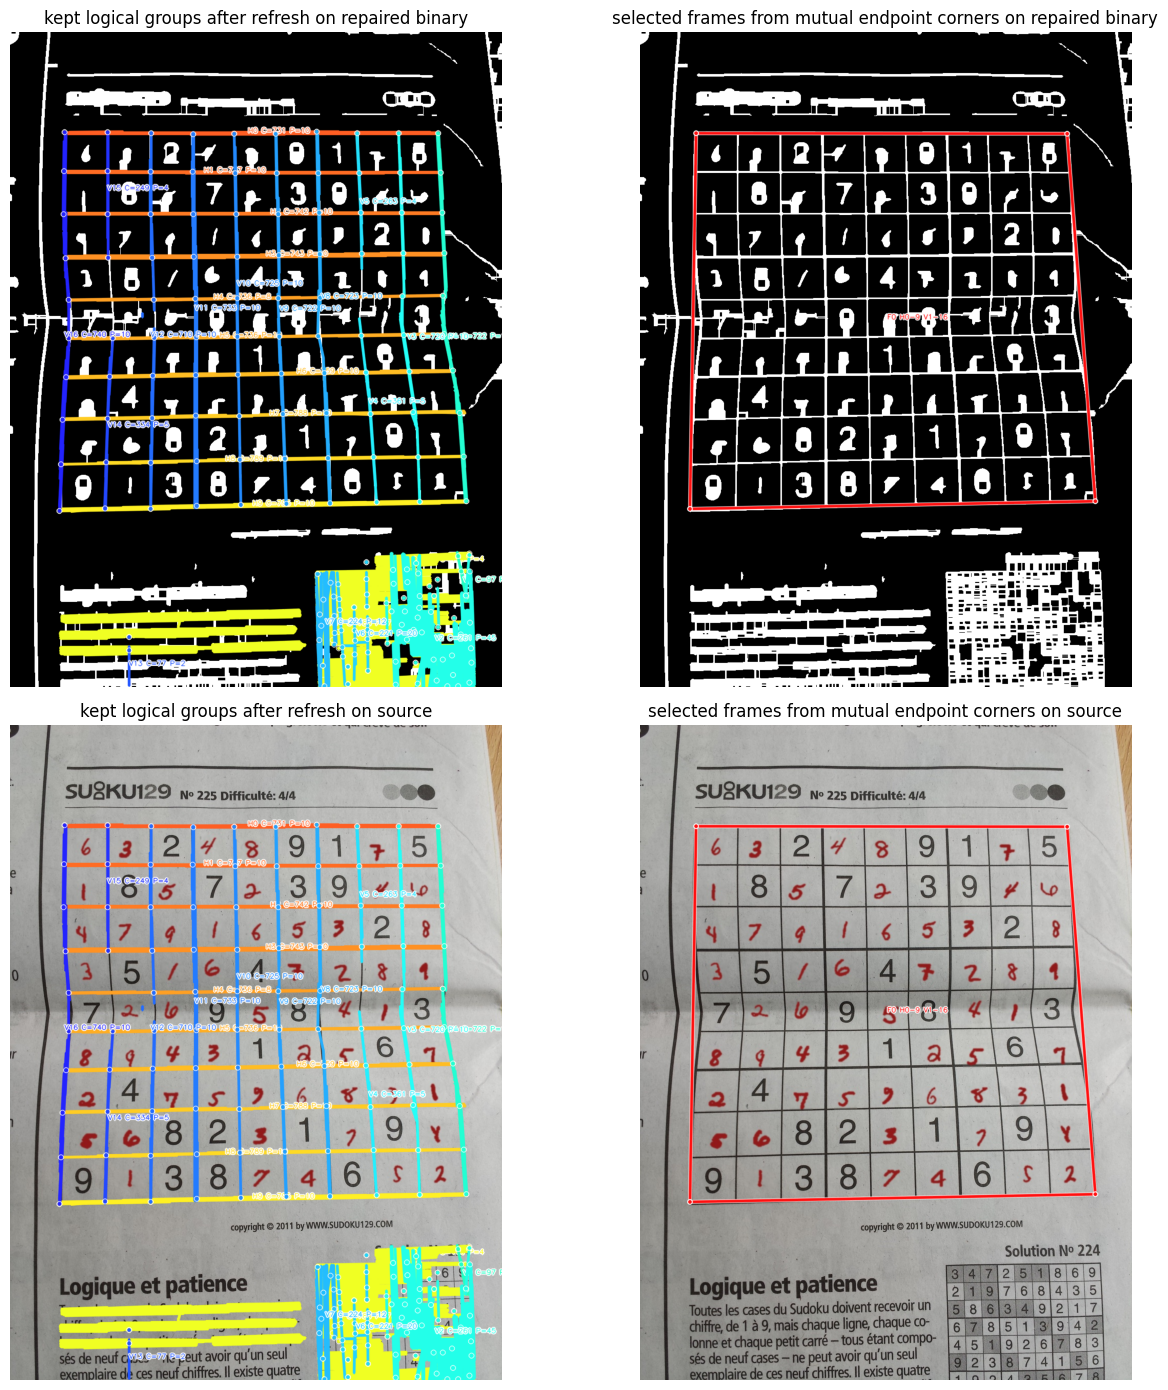

In [944]:
FRAME_DEBUG = run_frame_debug_analysis(
    PREPROCESS_RESULT.display_bgr,
    PREPROCESS_RESULT.selected_repaired_binary,
    LINE_DEBUG,
    CONFIG,
    API,
)
frame_detection_result = FRAME_DEBUG.frame_detection_result
selected_frames = FRAME_DEBUG.selected_frames

for line in describe_frame_debug_artifacts(FRAME_DEBUG):
    print(line)

API.plot_named_images(
    build_frame_debug_plot_items(FRAME_DEBUG, LINE_DEBUG),
    columns=2,
    figure_scale=7,
)

## 6. Warp planszy

W tej sekcji robimy czyste `A`:
- bierzemy bezpośrednio `LineFrame.corners`,
- wycinamy wykrytą planszę,
- rozciągamy ją do kwadratu,
- bez dodatkowych marginesów.

Na tym etapie nie porównujemy już alternatyw. Chcemy zobaczyć tylko najprostszy, bazowy warp oparty o aktualnie wykrytą ramkę.


Warp from the highest-priority selected frame:
Warp output: 600x600px, padding=0px

Frame corners used for warp corners:
  TL: (109.0, 199.0)
  TR: (833.0, 200.0)
  BR: (888.0, 917.0)
  BL: (97.0, 932.0)


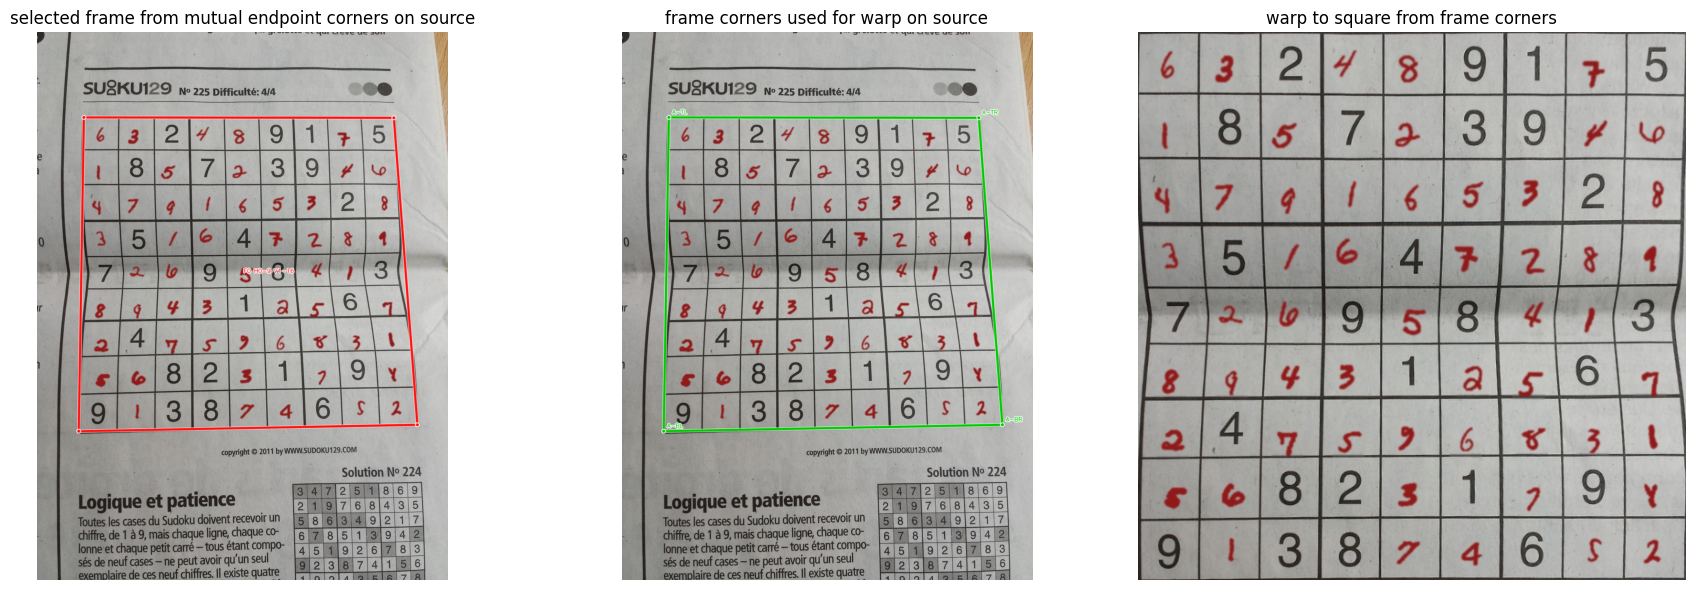

In [945]:
WARP_DEBUG = run_warp_debug_analysis(
    PREPROCESS_RESULT.display_bgr,
    FRAME_DEBUG,
    CONFIG,
)

for line in describe_warp_debug_artifacts(WARP_DEBUG, CONFIG):
    print(line)

API.plot_named_images(
    build_warp_debug_plot_items(FRAME_DEBUG, WARP_DEBUG),
    columns=3,
    figure_scale=6,
)